In [90]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from tqdm import tqdm

SEED = 42

PAPER = False

# Test lib

In [2]:
import torch 
from torch import nn, Tensor

import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

In [3]:
class Flow(nn.Module):
    def __init__(self, dim: int = 2, h: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, dim))
    
    def forward(self, t: Tensor, x_t: Tensor) -> Tensor:
        return self.net(torch.cat((t, x_t), -1))
    
    def step(self, x_t: Tensor, t_start: Tensor, t_end: Tensor) -> Tensor:
        t_start = t_start.view(1, 1).expand(x_t.shape[0], 1)
        
        return x_t + (t_end - t_start) * self(t=t_start + (t_end - t_start) / 2, x_t= x_t + self(x_t=x_t, t=t_start) * (t_end - t_start) / 2)

In [4]:
flow = Flow()

optimizer = torch.optim.Adam(flow.parameters(), 1e-2)
loss_fn = nn.MSELoss()

for _ in range(10000):
    x_1 = Tensor(make_moons(256, noise=0.15)[0])
    x_0 = torch.randn_like(x_1)
    t = torch.rand(len(x_1), 1)
    
    x_t = (1 - t) * x_0 + t * x_1
    dx_t = x_1 - x_0
    
    optimizer.zero_grad()
    loss_fn(flow(t=t, x_t=x_t), dx_t).backward()
    optimizer.step()

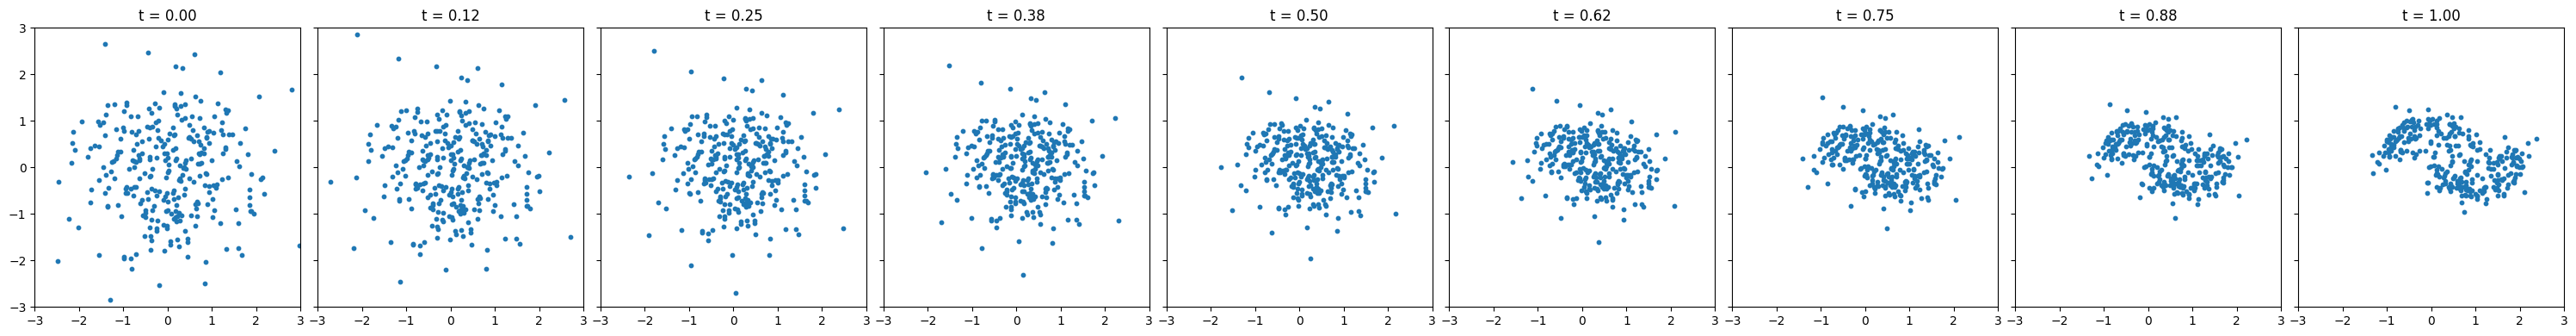

In [5]:
x = torch.randn(300, 2)
n_steps = 8
fig, axes = plt.subplots(1, n_steps + 1, figsize=(30, 4), sharex=True, sharey=True)
time_steps = torch.linspace(0, 1.0, n_steps + 1)

axes[0].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10)
axes[0].set_title(f't = {time_steps[0]:.2f}')
axes[0].set_xlim(-3.0, 3.0)
axes[0].set_ylim(-3.0, 3.0)

for i in range(n_steps):
    x = flow.step(x_t=x, t_start=time_steps[i], t_end=time_steps[i + 1])
    axes[i + 1].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10)
    axes[i + 1].set_title(f't = {time_steps[i + 1]:.2f}')

plt.tight_layout()
plt.show()

Citation from On the Relation between Rectified Flows and Optimal Transport

**Theorem 3 (Gaussian Case)**  
Assume that $(X_0, X_1) \sim \mathcal{N}(0, \Sigma)$ with 
$\Sigma = 
\begin{pmatrix}
\Sigma_{0} & \Sigma_{10}\\
\Sigma_{01} & \Sigma_{1}
\end{pmatrix}$,
for positive definite $\Sigma_{0}$ and $\Sigma_{1}$. Then, the following holds true.

The minimizer $v_t = \arg\min_{w_t} \mathcal{L}(w_t \, | \, X_0, X_1)$ of the loss function (1) is given by
$$
v_t(x) = \frac{1}{1 - t}
\Big (
((1 - t)\Sigma_{01} + t\Sigma_1)\Sigma_t^{-1}
- \text{Id}
\Big )
x
$$


where
$\Sigma_{t} = \text{Cov}(X_t) = (1 - t)^2 \Sigma_{0} + (1 - t)t(\Sigma_{01} + \Sigma_{10}) + t^2 \Sigma_{1}$.




Then we can write
$$
J_t = \nabla_x v_t(x) = \frac{1}{1 - t}
\Big (
((1 - t)\Sigma_{01} + t\Sigma_1)\Sigma_t^{-1}
- \text{Id}
\Big )
$$,

where
$\Sigma_{t} = \text{Cov}(X_t) = (1 - t)^2 \Sigma_{0} + (1 - t)t(\Sigma_{01} + \Sigma_{10}) + t^2 \Sigma_{1}$.

# Normal to normal

Case 1:  
$X_0 \sim \mathcal{N}(0, \Sigma_{0})$ with
$$\Sigma_{0} = 
\begin{pmatrix}
9 & 0\\
0 & 9
\end{pmatrix}$$

In [6]:
torch.manual_seed(SEED)
flow = Flow()

optimizer = torch.optim.Adam(flow.parameters(), 1e-2)
loss_fn = nn.MSELoss()

for _ in range(10000):
    x_1 = torch.randn(256, 2) * 3.0 # data
    x_0 = torch.randn_like(x_1)
    t = torch.rand(len(x_1), 1)
    
    x_t = (1 - t) * x_0 + t * x_1
    dx_t = x_1 - x_0
    
    optimizer.zero_grad()
    loss_fn(flow(t=t, x_t=x_t), dx_t).backward()
    optimizer.step()

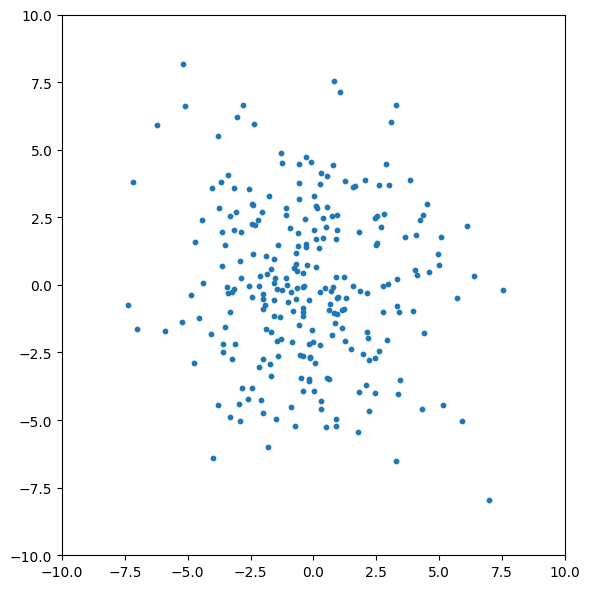

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6), sharex=True, sharey=True)

ax.scatter(x_1.detach()[:, 0], x_1.detach()[:, 1], s=10)
ax.set_xlim(-10.0, 10.0)
ax.set_ylim(-10.0, 10.0)

plt.tight_layout()
plt.show()

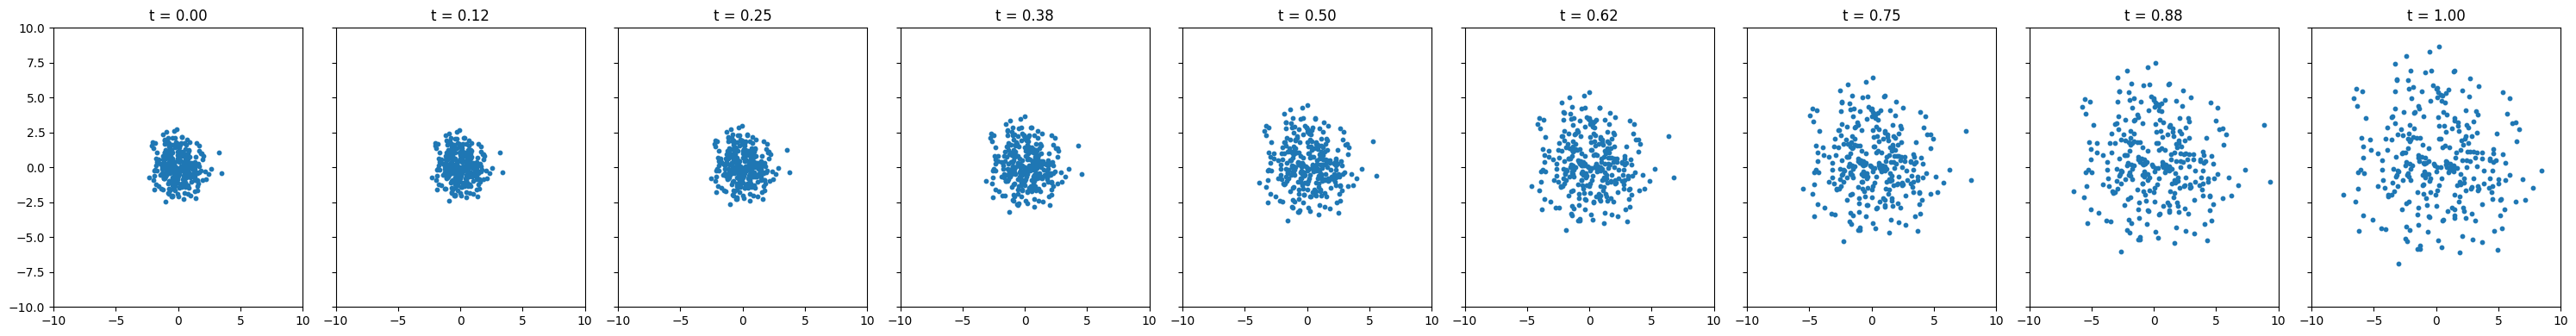

In [8]:
x = torch.randn(300, 2)
n_steps = 8
fig, axes = plt.subplots(1, n_steps + 1, figsize=(30, 4), sharex=True, sharey=True)
time_steps = torch.linspace(0, 1.0, n_steps + 1)

axes[0].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10)
axes[0].set_title(f't = {time_steps[0]:.2f}')
axes[0].set_xlim(-10.0, 10.0)
axes[0].set_ylim(-10.0, 10.0)

for i in range(n_steps):
    x = flow.step(x_t=x, t_start=time_steps[i], t_end=time_steps[i + 1])
    axes[i + 1].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10)
    axes[i + 1].set_title(f't = {time_steps[i + 1]:.2f}')

plt.tight_layout()
plt.show()

Citation from On the Relation between Rectified Flows and Optimal Transport

**Theorem 3 (Gaussian Case)**  
Assume that $(X_0, X_1) \sim \mathcal{N}(0, \Sigma)$ with 
$\Sigma = 
\begin{pmatrix}
\Sigma_{0} & \Sigma_{10}\\
\Sigma_{01} & \Sigma_{1}
\end{pmatrix}$,
for positive definite $\Sigma_{0}$ and $\Sigma_{1}$. Then, the following holds true.

The minimizer $v_t = \arg\min_{w_t} \mathcal{L}(w_t \, | \, X_0, X_1)$ of the loss function (1) is given by
$$
v_t(x) = \frac{1}{1 - t}
\Big (
((1 - t)\Sigma_{01} + t\Sigma_1)\Sigma_t^{-1}
- \text{Id}
\Big )
x
$$


where
$\Sigma_{t} = \text{Cov}(X_t) = (1 - t)^2 \Sigma_{0} + (1 - t)t(\Sigma_{01} + \Sigma_{10}) + t^2 \Sigma_{1}$.




$p_0 \sim \mathcal{N}$ and $p_1 \sim p_\text{data}$

ligne de v

In [48]:
def theory_basis_normal_coupling(coupling, t):
    d = coupling.shape[0] // 2
    Sigma_0 = coupling[:d, :d]
    Sigma_1 = coupling[d:, d:]
    Sigma_10 = coupling[:d, d:]
    Sigma_01 = coupling[d:, :d]

    Sigma_t = (1 - t) ** 2 * Sigma_0 + (1 - t) * t * (Sigma_01 + Sigma_10) + t ** 2 * Sigma_1

    Jac_v_t = (1 / (1 - t)) * (((1 - t) * Sigma_01 + t * Sigma_1) @ torch.linalg.inv(Sigma_t) - torch.eye(d))
    U, S, Vh = torch.linalg.svd(Jac_v_t)
    return Vh

coupling = Tensor([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 9, 0], [0, 0, 0, 9]])
t = 0.5
theory_basis_normal_coupling(coupling, t)

tensor([[1., 0.],
        [0., 1.]])

In [ ]:
import torch

def compute_jacobian(flow, t, x):
    x = x.detach().clone().requires_grad_(True)

    def flow_fn(x_):
        t_tensor = torch.tensor([t], dtype=x_.dtype, device=x_.device)
        return flow(t=t_tensor, x_t=x_)

    # jac: shape (out_dim, in_dim)
    jac = torch.autograd.functional.jacobian(flow_fn, x, create_graph=False)

    U, S, Vh = torch.linalg.svd(jac)
    return Vh, jac

Vh, jac = compute_jacobian(flow, t=0.5, x=torch.randn(2))
Vh


tensor([[-0.9990, -0.0450],
        [-0.0450,  0.9990]])

# high dim

In [138]:
torch.manual_seed(SEED)
flow = Flow(dim=100)

optimizer = torch.optim.Adam(flow.parameters(), 1e-2)
loss_fn = nn.MSELoss()

for _ in tqdm(range(10000)):
    x_1 = torch.randn(2560, 100) * 3.0 # data
    x_0 = torch.randn_like(x_1)
    t = torch.rand(len(x_1), 1)
    
    x_t = (1 - t) * x_0 + t * x_1
    dx_t = x_1 - x_0
    
    optimizer.zero_grad()
    loss_fn(flow(t=t, x_t=x_t), dx_t).backward()
    optimizer.step()

100%|██████████| 10000/10000 [01:01<00:00, 161.65it/s]


In [139]:
import torch
torch.manual_seed(SEED)

def compute_jacobian(flow, t, x):
    x = x.detach().clone().requires_grad_(True)

    def flow_fn(x_):
        t_tensor = torch.tensor([t], dtype=x_.dtype, device=x_.device)
        return flow(t=t_tensor, x_t=x_)

    # jac: shape (out_dim, in_dim)
    jac = torch.autograd.functional.jacobian(flow_fn, x, create_graph=False)

    U, S, Vh = torch.linalg.svd(jac)
    return Vh, jac

Vh, jac = compute_jacobian(flow, t=0.5, x=torch.randn(100))
Vh[:, 0]

tensor([-0.0140,  0.0812, -0.0672,  0.0718, -0.0468,  0.1943, -0.0216,  0.1040,
        -0.0341,  0.1653, -0.0317,  0.0044,  0.0603, -0.0514,  0.1692, -0.1809,
         0.1348,  0.0704, -0.0494, -0.0306,  0.0370,  0.0717, -0.0667,  0.0370,
         0.0062,  0.1799, -0.0480, -0.0808,  0.0515,  0.0724,  0.0207, -0.1098,
        -0.0718,  0.1423, -0.0092, -0.0009, -0.0090, -0.0750,  0.1709, -0.2140,
        -0.0854, -0.0082,  0.0733,  0.2047, -0.1068, -0.1496,  0.1154,  0.0054,
        -0.1040,  0.1201, -0.0399, -0.0492,  0.2269, -0.0819,  0.1106, -0.0872,
         0.2588, -0.0168,  0.0024,  0.1026, -0.0733,  0.0084, -0.0443,  0.1421,
        -0.0602,  0.0324,  0.0000,  0.0000,  0.0000,  0.2624,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0667,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.1368,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000, -0.1606,  0.0000,
         0.0000, -0.4378,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.00

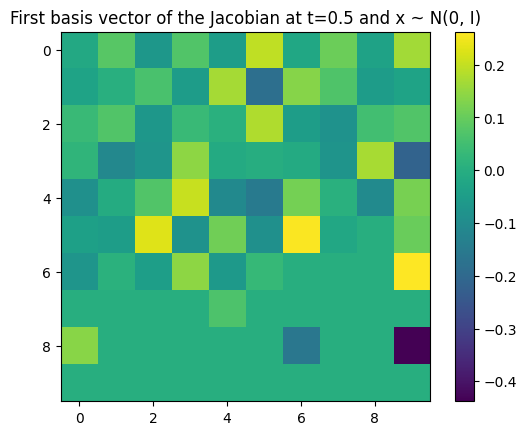

In [140]:
torch.manual_seed(SEED)
# this is the first basis vector of the Jacobian of the flow at t=0.5 and x ~ N(0, I) so the one with the largest singular value, i.e. the direction of maximal expansion of the flow at this point
Vh[:, 0]
# now we print this vector as an image with color
plt.imshow(Vh[:, 0].view(10, 10).detach().numpy(), cmap='viridis')
plt.colorbar()
if PAPER:
    plt.savefig('basis_vector.png', dpi=300)
else:
    plt.title('First basis vector of the Jacobian at t=0.5 and x ~ N(0, I)')
plt.show()

In [102]:
# same coupling as before but with dim=100
coupling = torch.cat((torch.cat((torch.eye(100), torch.eye(100)), dim=1), torch.cat((torch.eye(100), 9 * torch.eye(100)), dim=1)), dim=0) 
t = 0.5
Vh_2 = theory_basis_normal_coupling(coupling, t)
Vh_2[:, 0]

tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [170]:
import seaborn as sns
sns.color_palette("colorblind", as_cmap=True)

['#0173B2',
 '#DE8F05',
 '#029E73',
 '#D55E00',
 '#CC78BC',
 '#CA9161',
 '#FBAFE4',
 '#949494',
 '#ECE133',
 '#56B4E9']

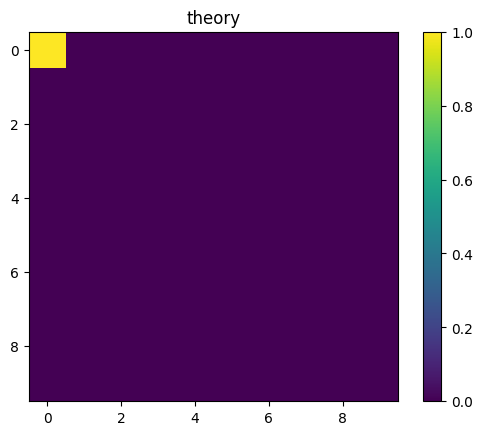

In [172]:
Vh_2[:, 0]
# now we print this vector as an image with color
plt.imshow(Vh_2[:, 0].view(10, 10).detach().numpy(), cmap='viridis')
plt.colorbar()
if PAPER:
    plt.savefig('basis_vector.png', dpi=300)
else:
    plt.title('theory')
plt.show()

100%|██████████| 10/10 [00:00<00:00, 710.18it/s]


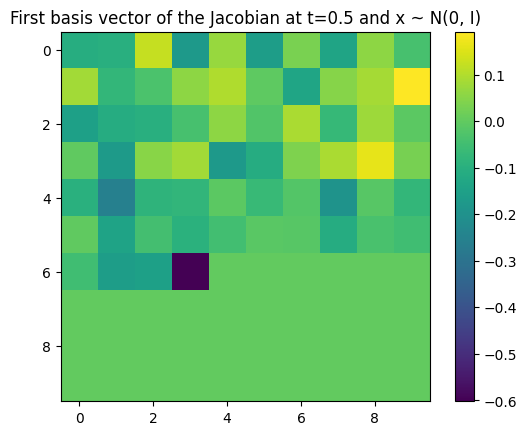

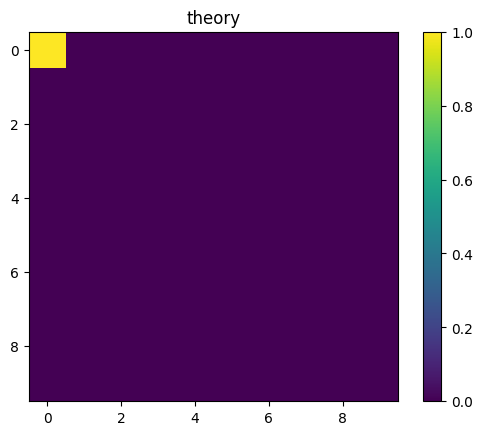

In [158]:
torch.manual_seed(SEED)
flow = Flow(dim=100)
n_sample = 256
n_epochs = 10

optimizer = torch.optim.Adam(flow.parameters(), 1e-2)
loss_fn = nn.MSELoss()

for _ in tqdm(range(n_epochs)):
    x_1 = torch.randn(n_sample, 100) * 3.0 # data
    x_0 = torch.randn_like(x_1)
    t = torch.rand(len(x_1), 1)
    
    x_t = (1 - t) * x_0 + t * x_1
    dx_t = x_1 - x_0
    
    optimizer.zero_grad()
    loss_fn(flow(t=t, x_t=x_t), dx_t).backward()
    optimizer.step()

Vh, jac = compute_jacobian(flow, t=0.5, x=torch.randn(100))

# now we print this vector as an image with color
plt.imshow(Vh[:, 0].view(10, 10).detach().numpy(), cmap='viridis')
plt.colorbar()
if PAPER:
    plt.savefig('basis_vector.png', dpi=300)
else:
    plt.title('First basis vector of the Jacobian at t=0.5 and x ~ N(0, I)')

plt.show()
coupling = torch.cat((torch.cat((torch.eye(100), torch.eye(100)), dim=1), torch.cat((torch.eye(100), 9 * torch.eye(100)), dim=1)), dim=0) 
t = 0.5
Vh_2 = theory_basis_normal_coupling(coupling, t)
Vh_2[:, 0]
# now we print this vector as an image with color
plt.imshow(Vh_2[:, 0].view(10, 10).detach().numpy(), cmap='viridis')
plt.colorbar()
if PAPER:
    plt.savefig('basis_vector.png', dpi=300)
else:
    plt.title('theory')
plt.show()
